In [2]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import xarray as xr
import os

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch
import astropy.constants as const

import pandas as pd



In [ ]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44]
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii

star_temperature = [5261,4570,3381,4850,4440,5342,4884,4914] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr

# columns in the csv file
#pressure = 0
#terminator = 1
#substellar = 2
#average = 3

## Simulations Visualizations

In [4]:
#select which simulation batch to plot
#[0: standard; 1: 1 H ocean; 2: 10 H ocean; 3: escape]
batches = [0,1,2,3]

In [5]:
for batch in batches:
    for i, name in enumerate(planet_names):

        #read-in the atmospheric composition
        atm_file = None

        if batch == 0:
            name = name
        elif batch == 1:
            name = f"{name}_1"
        elif batch == 2:
            name = f"{name}_10"
        elif batch == 3:
            name = f"{name}_escape"
        else:
            print("Invalid batch selection.")
            continue

        #print(f"Processing planet: {name}")
        
        for file in os.listdir(f"PLANETS/{name}/"):
            if file.endswith("atm.nc"):
                atm_file = os.path.join(f"PLANETS/{name}/", file)
                #save filename without extension
                filename = os.path.splitext(atm_file)[0]
                break

        ds = xr.open_dataset(atm_file)

        #list all variables in dataset
        #print("Variables in dataset:")
        #for var in ds.variables:
        #    print(f"  {var}")

        #extract gas names
        gases = np.array(ds['gases'])
        gases = [m.decode().strip() for m in ds["gases"].values]
        vmr = np.array(ds['x_gas'])

        #extract mmw
        mmw = np.array(ds['mmw'])

        pressure = np.array(ds['p']) #pressure in Pa
        pmax = pressure.max()
        pmin = pressure.min()

        radius = float(ds['planet_radius']) #planet radius in m
        #convert to Jupiter radii
        radius = radius / const.R_jup.value

        #get mixing ratio of each molecule
        H2O_x = float(vmr[:, gases.index('H2O')][0])
        CO2_x = float(vmr[:, gases.index('CO2')][0])
        CH4_x = float(vmr[:, gases.index('CH4')][0])
        CO_x = float(vmr[:, gases.index('CO')][0])
        NH3_x = float(vmr[:, gases.index('NH3')][0])
        N2_x = float(vmr[:, gases.index('N2')][0])
        SO2_x = float(vmr[:, gases.index('SO2')][0])
        S2_x = float(vmr[:, gases.index('S2')][0])
        O2_x = float(vmr[:, gases.index('O2')][0])
        H2_x = float(vmr[:, gases.index('H2')][0])
        H2S_x = float(vmr[:, gases.index('H2S')][0])

        locals()[f"{name}_composition"] = [H2O_x,CO2_x,CH4_x,CO_x,NH3_x,N2_x,SO2_x,S2_x,O2_x,H2_x,H2S_x]
        #save surface pressure and surface temperature
        locals()[f"{name}_pmax"] = pmax
        locals()[f"{name}_surface_temp"] = float(ds['tmp_surf'])
        locals()[f"{name}_mmw"] = mmw[0]


In [ ]:
#show nc files content
for var in ds.variables:
    print(f"{var}: {ds[var]}")

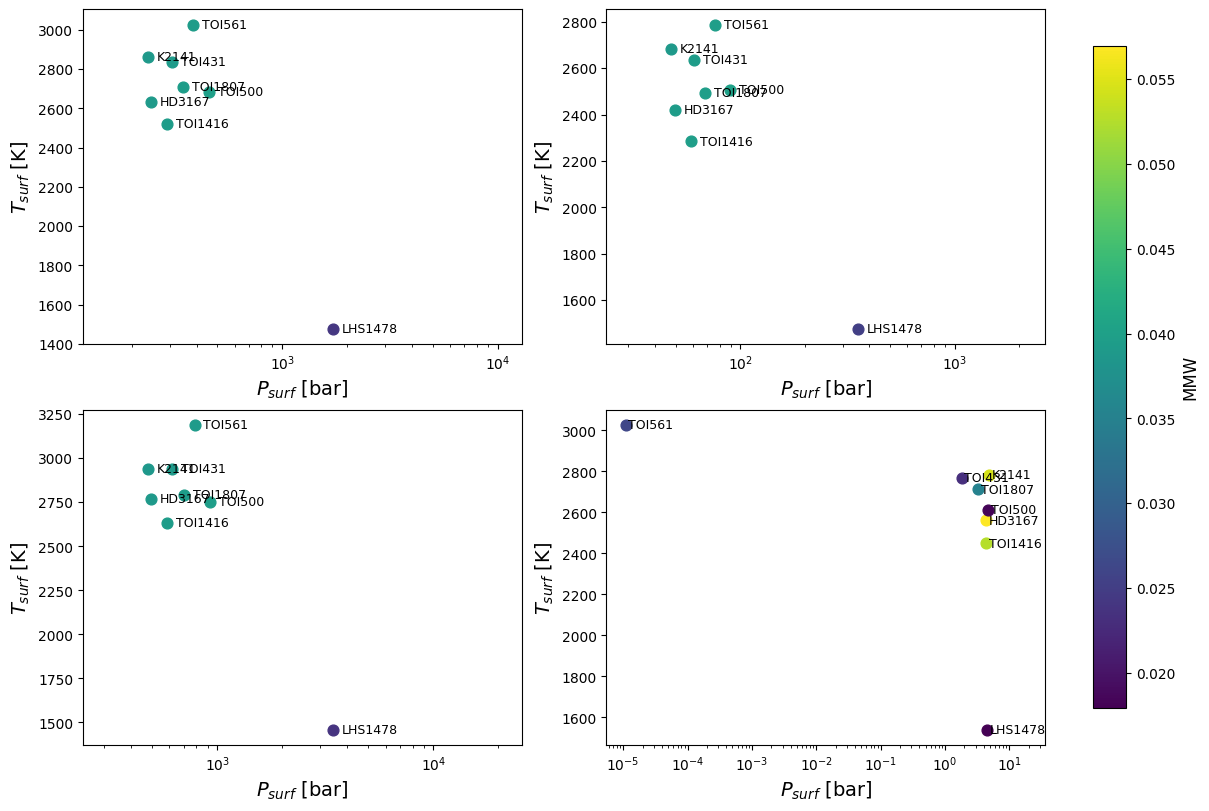

In [6]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    constrained_layout=True
)
axes = axes.flatten()

batches = {
    0: "",
    1: "_1",
    2: "_10",
    3: "_escape",
}

mmw_all = []
for suffix in batches.values():
    for pname in planet_names:
        name = f"{pname}{suffix}"
        mmw_all.append(float(globals()[f"{name}_mmw"]))

vmin = min(mmw_all)
vmax = max(mmw_all)

sc_ref = None

for ax, (batch, suffix) in zip(axes, batches.items()):

    ax.set_xscale("log")
    ax.set_xlabel(r"$P_{surf}$ [bar]", fontsize=14)
    ax.set_ylabel(r"$T_{surf}$ [K]", fontsize=14)

    pvals = []

    for pname in planet_names:

        name = f"{pname}{suffix}"

        pmax = globals()[f"{name}_pmax"] / 1e5
        t_surf = globals()[f"{name}_surface_temp"]
        mmw = float(globals()[f"{name}_mmw"])

        pvals.append(pmax)

        sc_ref = ax.scatter(
            pmax,
            t_surf,
            c=mmw,
            cmap="viridis",
            s=60,
            vmin=vmin,
            vmax=vmax
        )

        ax.text(
            pmax * 1.1,
            t_surf,
            pname,
            fontsize=9,
            va="center",
            ha="left",
            clip_on=True
        )

    xmax = max(pvals)
    ax.set_xlim(min(pvals) / 2, xmax * 7.5)

cbar = fig.colorbar(
    sc_ref,
    ax=axes,
    location="right",
    shrink=0.9
)

cbar.set_label("MMW", fontsize=12)

plt.savefig("plots/pressure_temperature_mmw.pdf", format="pdf")
plt.show()



In [7]:
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#CC79A7",  # purple
    "#999999",  # grey
    "#332288",  # dark blue
    "#AA4499",  # magenta
    "#44AA99",  # teal
    "#882255",  # wine
]


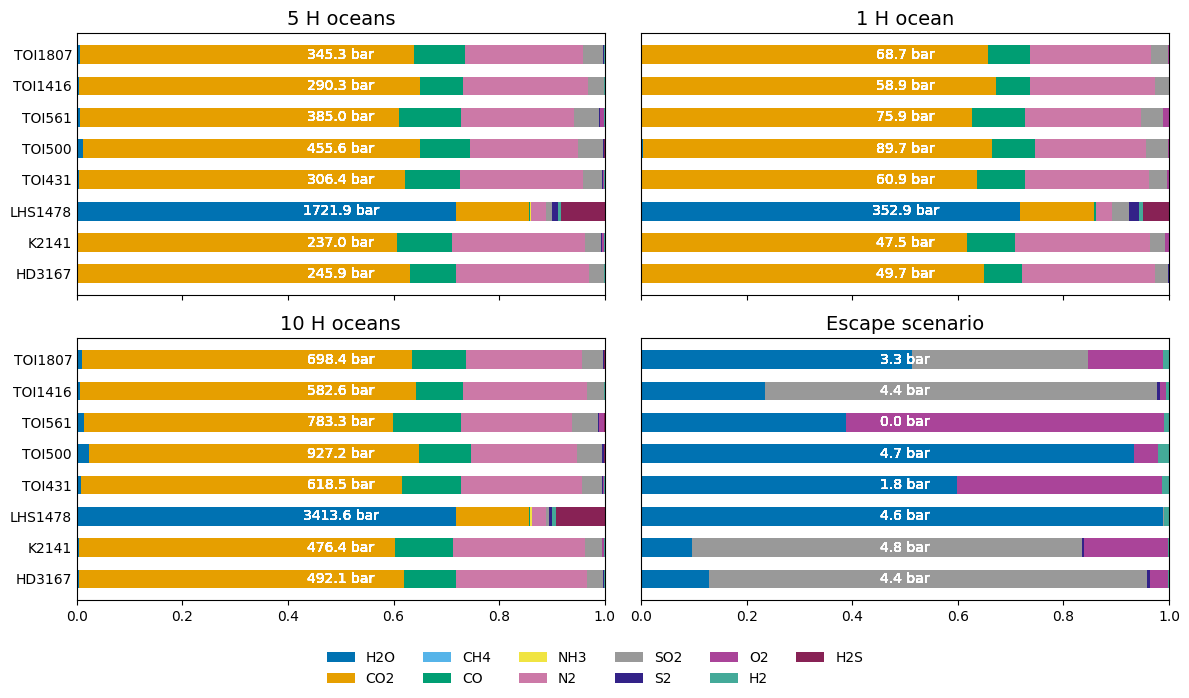

In [10]:
batches = {0: "",1: "_1",2: "_10",3: "_escape",}

molecule_names = ["H2O", "CO2", "CH4", "CO", "NH3",
                  "N2", "SO2", "S2", "O2", "H2", "H2S"]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 7),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

y_positions = np.arange(len(planet_names))
bar_height = 0.6

for ax, (batch, suffix) in zip(axes, batches.items()):

    for i, pname in enumerate(planet_names):
        name = f"{pname}{suffix}"

        comp = np.array(globals()[f"{name}_composition"])
        comp = comp / comp.sum()

        pmax = globals()[f"{name}_pmax"] / 1e5

        left = 0.0
        for frac, color in zip(comp, colors):
            ax.barh(
                i,
                frac,
                left=left,
                height=bar_height,
                color=color,
                edgecolor="none"
            )
            left += frac

            ax.text(
            0.5,
            i,
            f"{pmax:.1f} bar",
            va="center",
            ha="center",
            fontsize=10,
            color="white"
        )

    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)
    if batch == 0:
        ax.set_title(f"5 H oceans", fontsize=14)
    elif batch == 1:
        ax.set_title(f"1 H ocean", fontsize=14)
    elif batch == 2:
        ax.set_title(f"10 H oceans", fontsize=14)
    elif batch == 3:
        ax.set_title(f"Escape scenario", fontsize=14)

for ax in (axes[0], axes[2]):  # left column
    ax.set_yticks(y_positions)
    ax.set_yticklabels(planet_names, fontsize=10)
    ax.tick_params(labelleft=True)

for ax in (axes[1], axes[3]):  # right column
    ax.tick_params(labelleft=False)

legend_handles = [
    Patch(facecolor=c, label=m)
    for c, m in zip(colors, molecule_names)
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=6,
    fontsize=10,
    frameon=False
)

fig.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("plots/atmospheric_composition.pdf")
plt.show()


### T-P profile

Processing batch: 


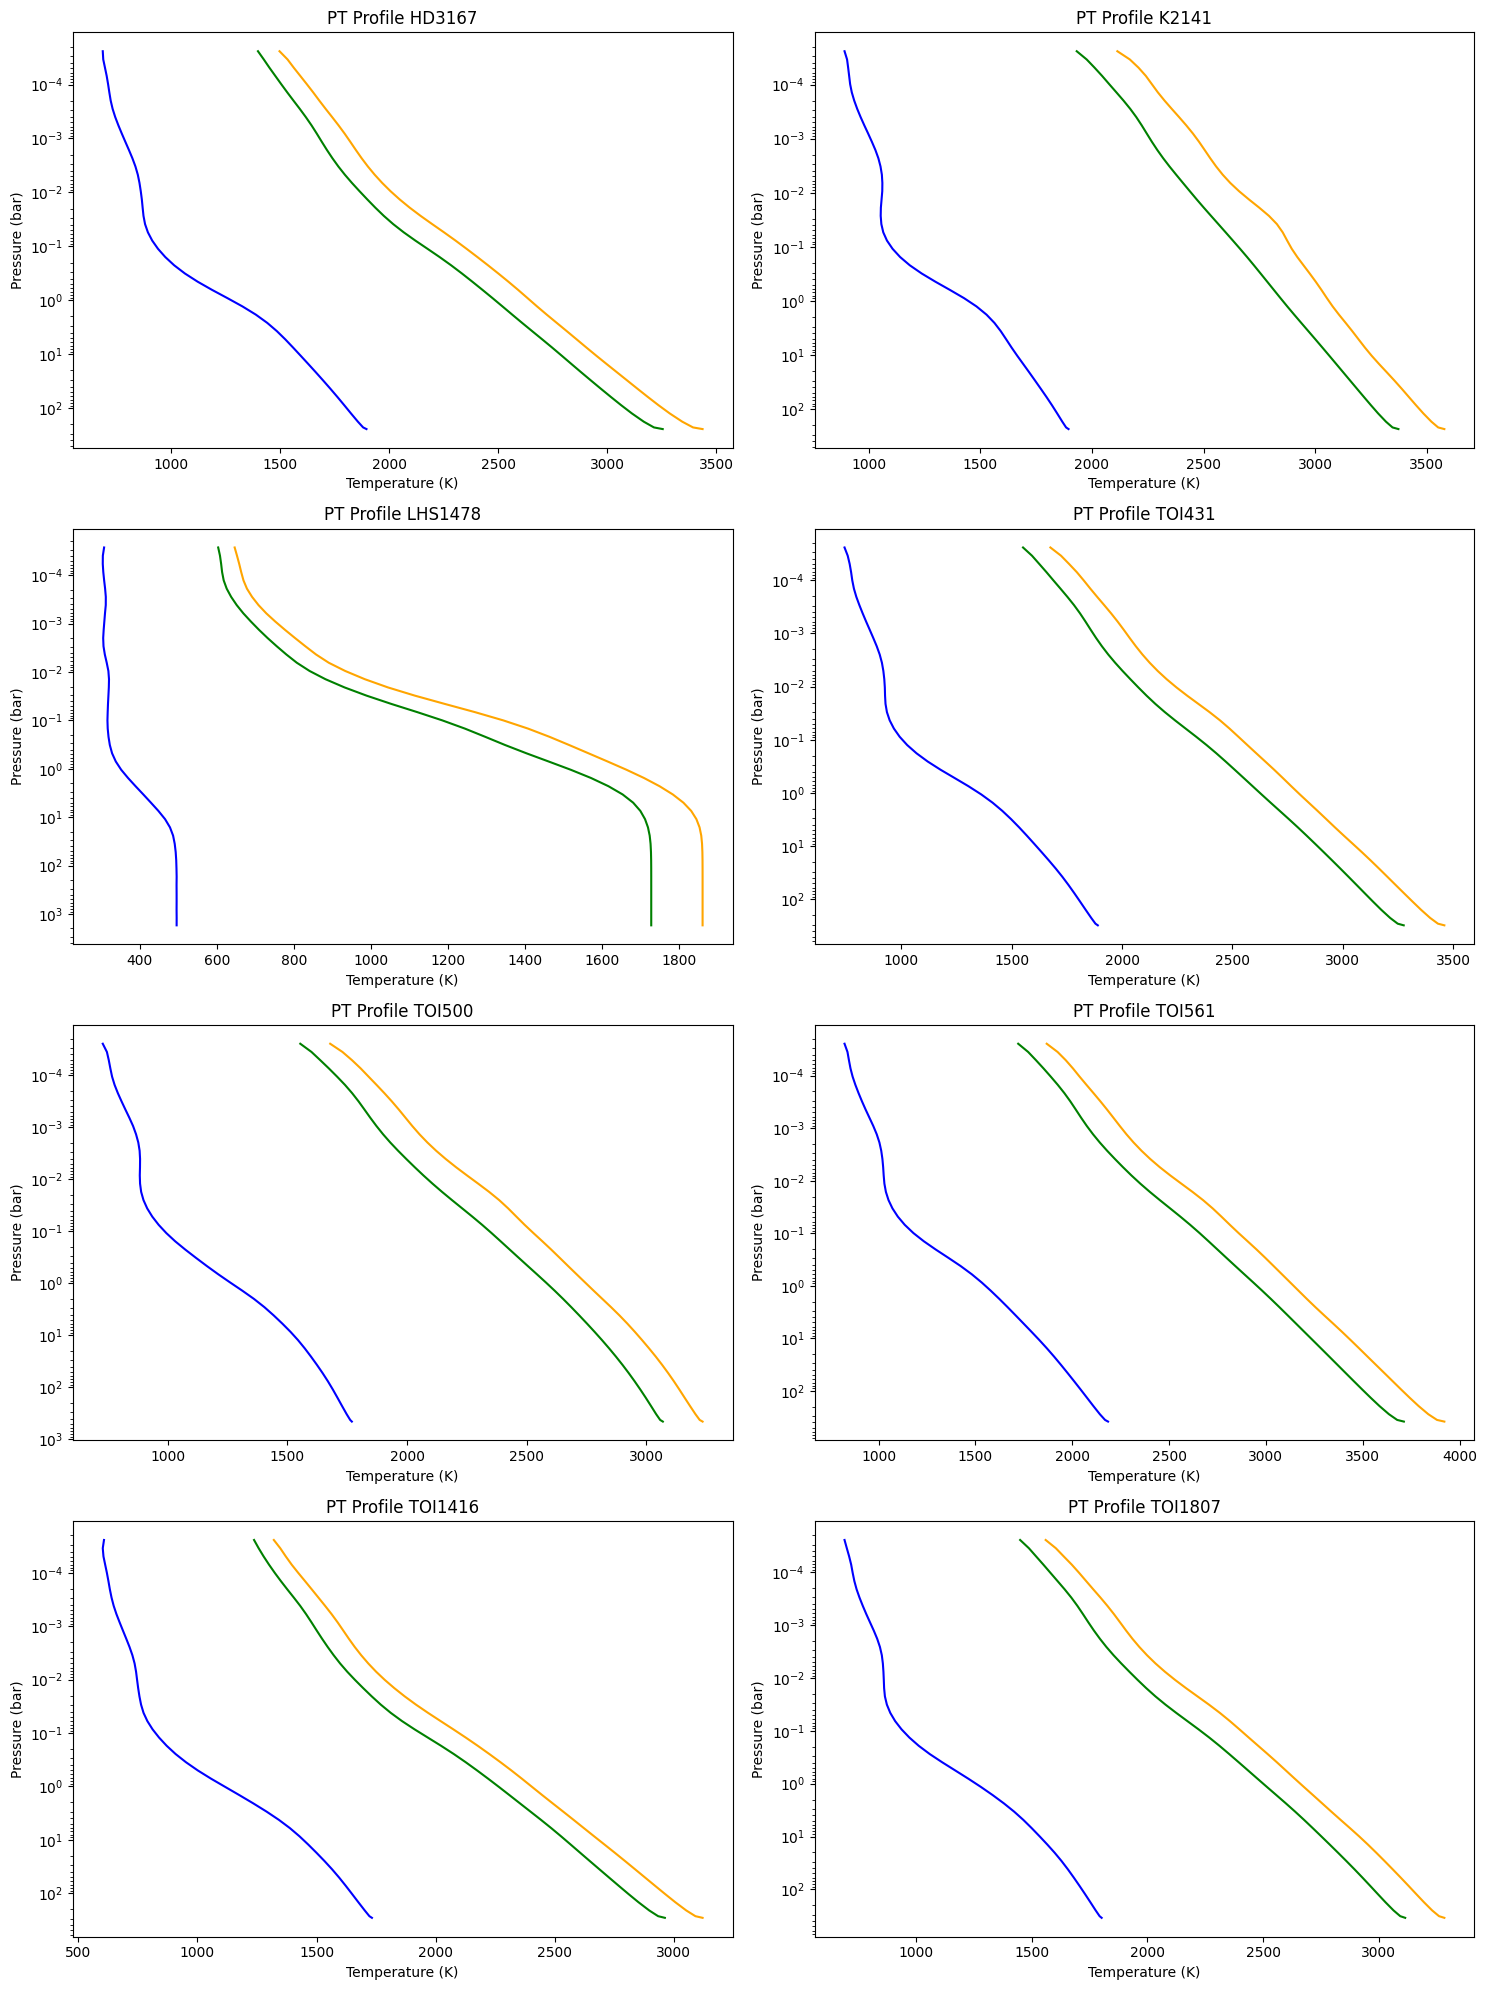

Processing batch: _1


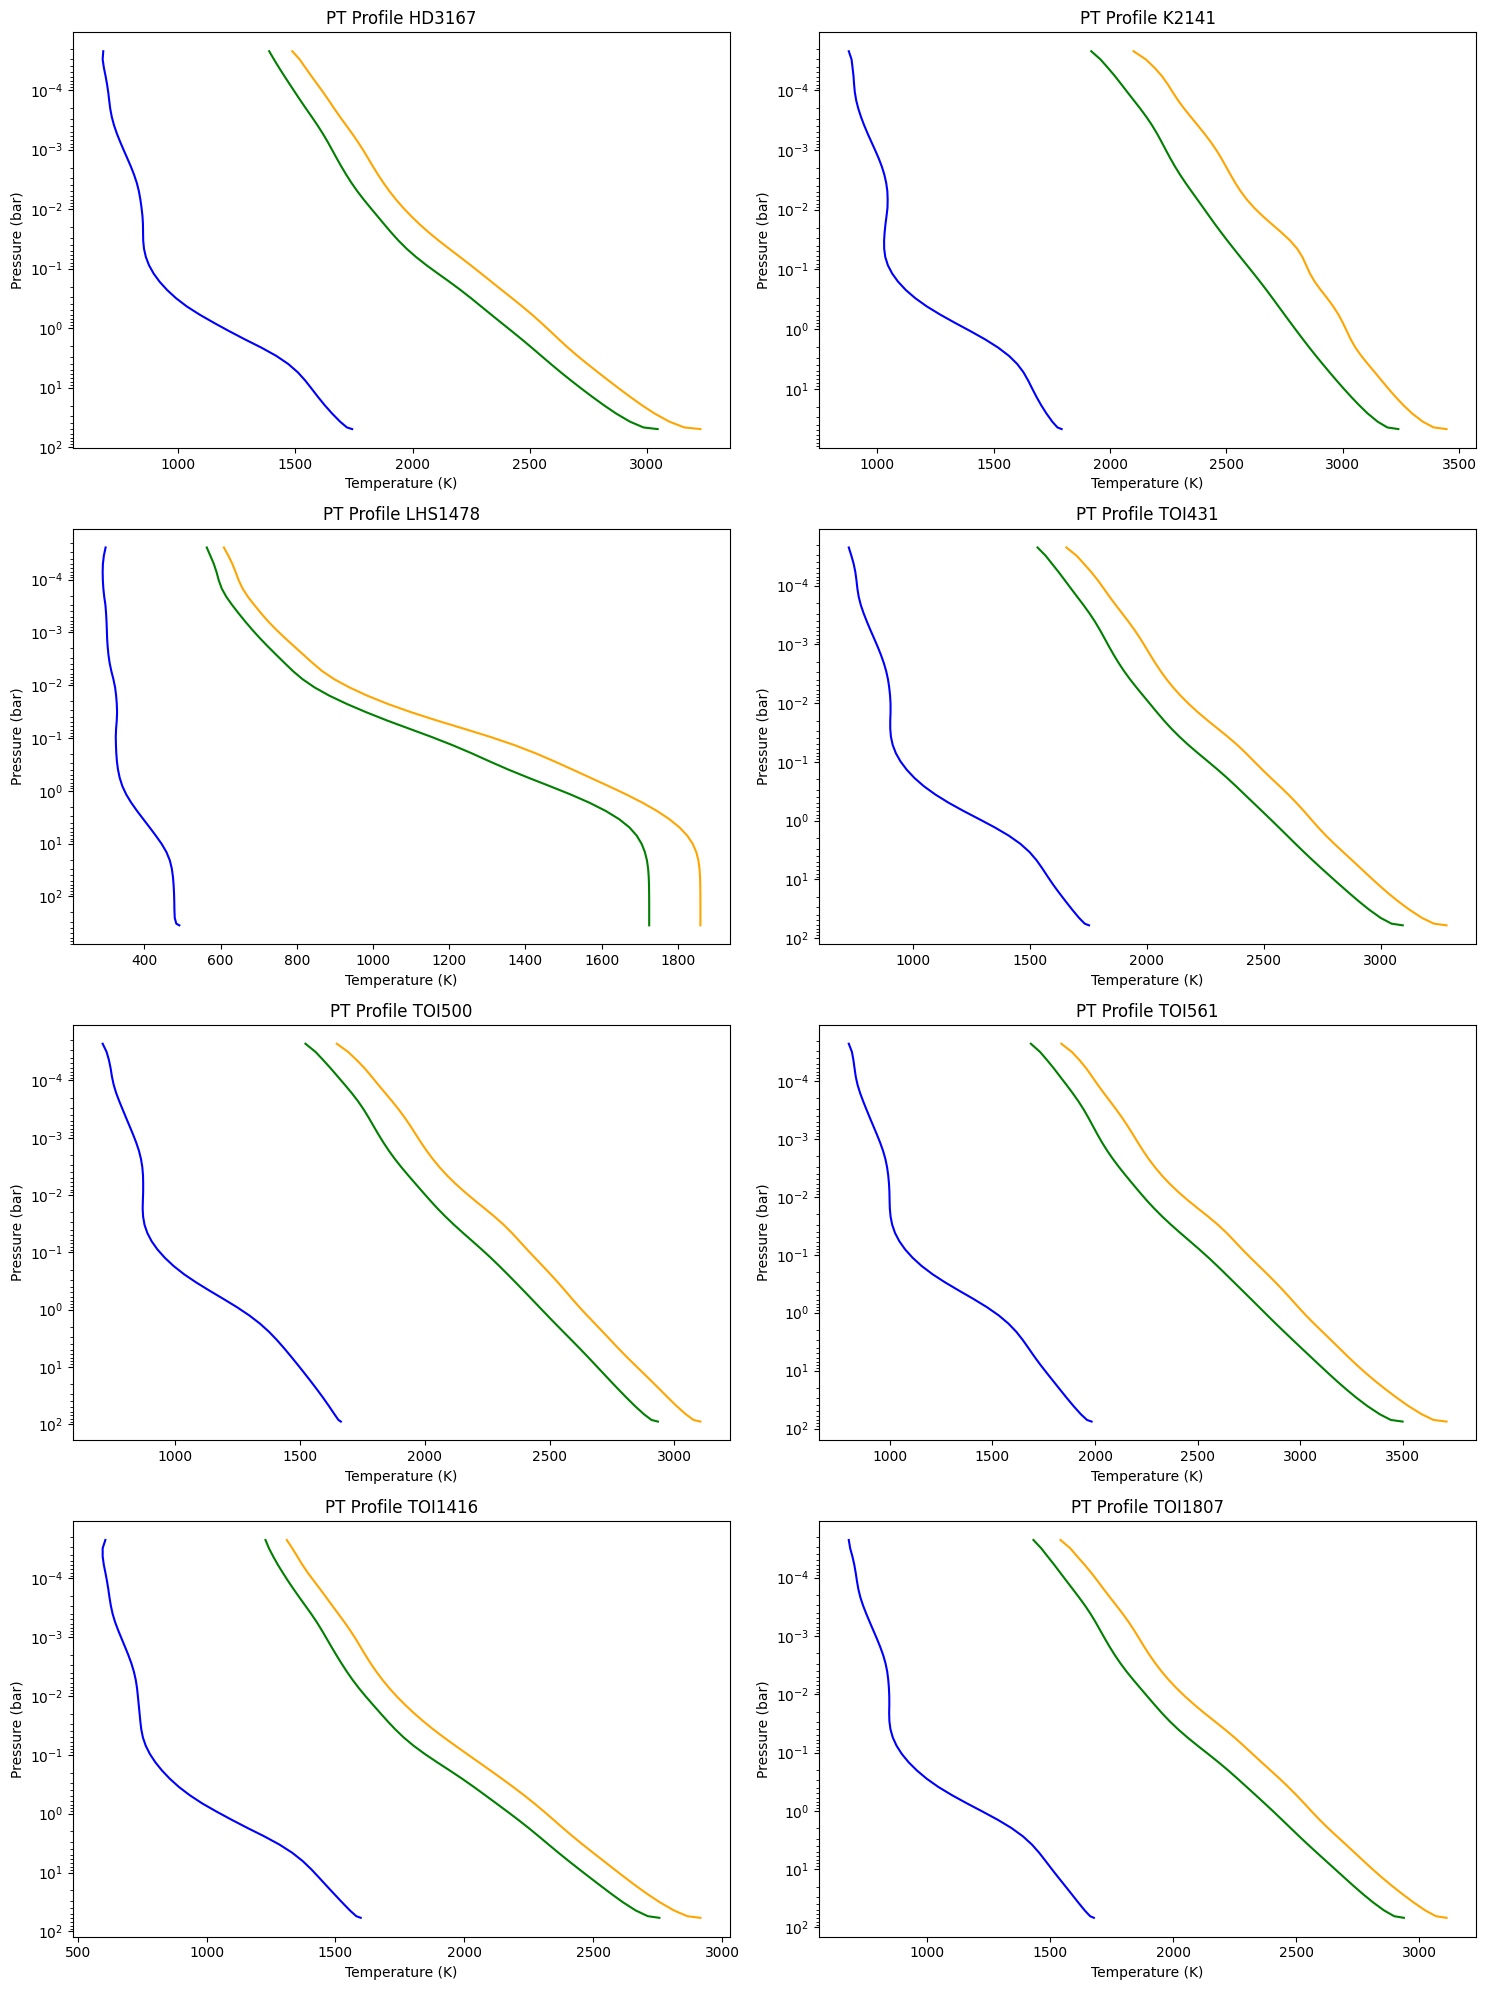

Processing batch: _10


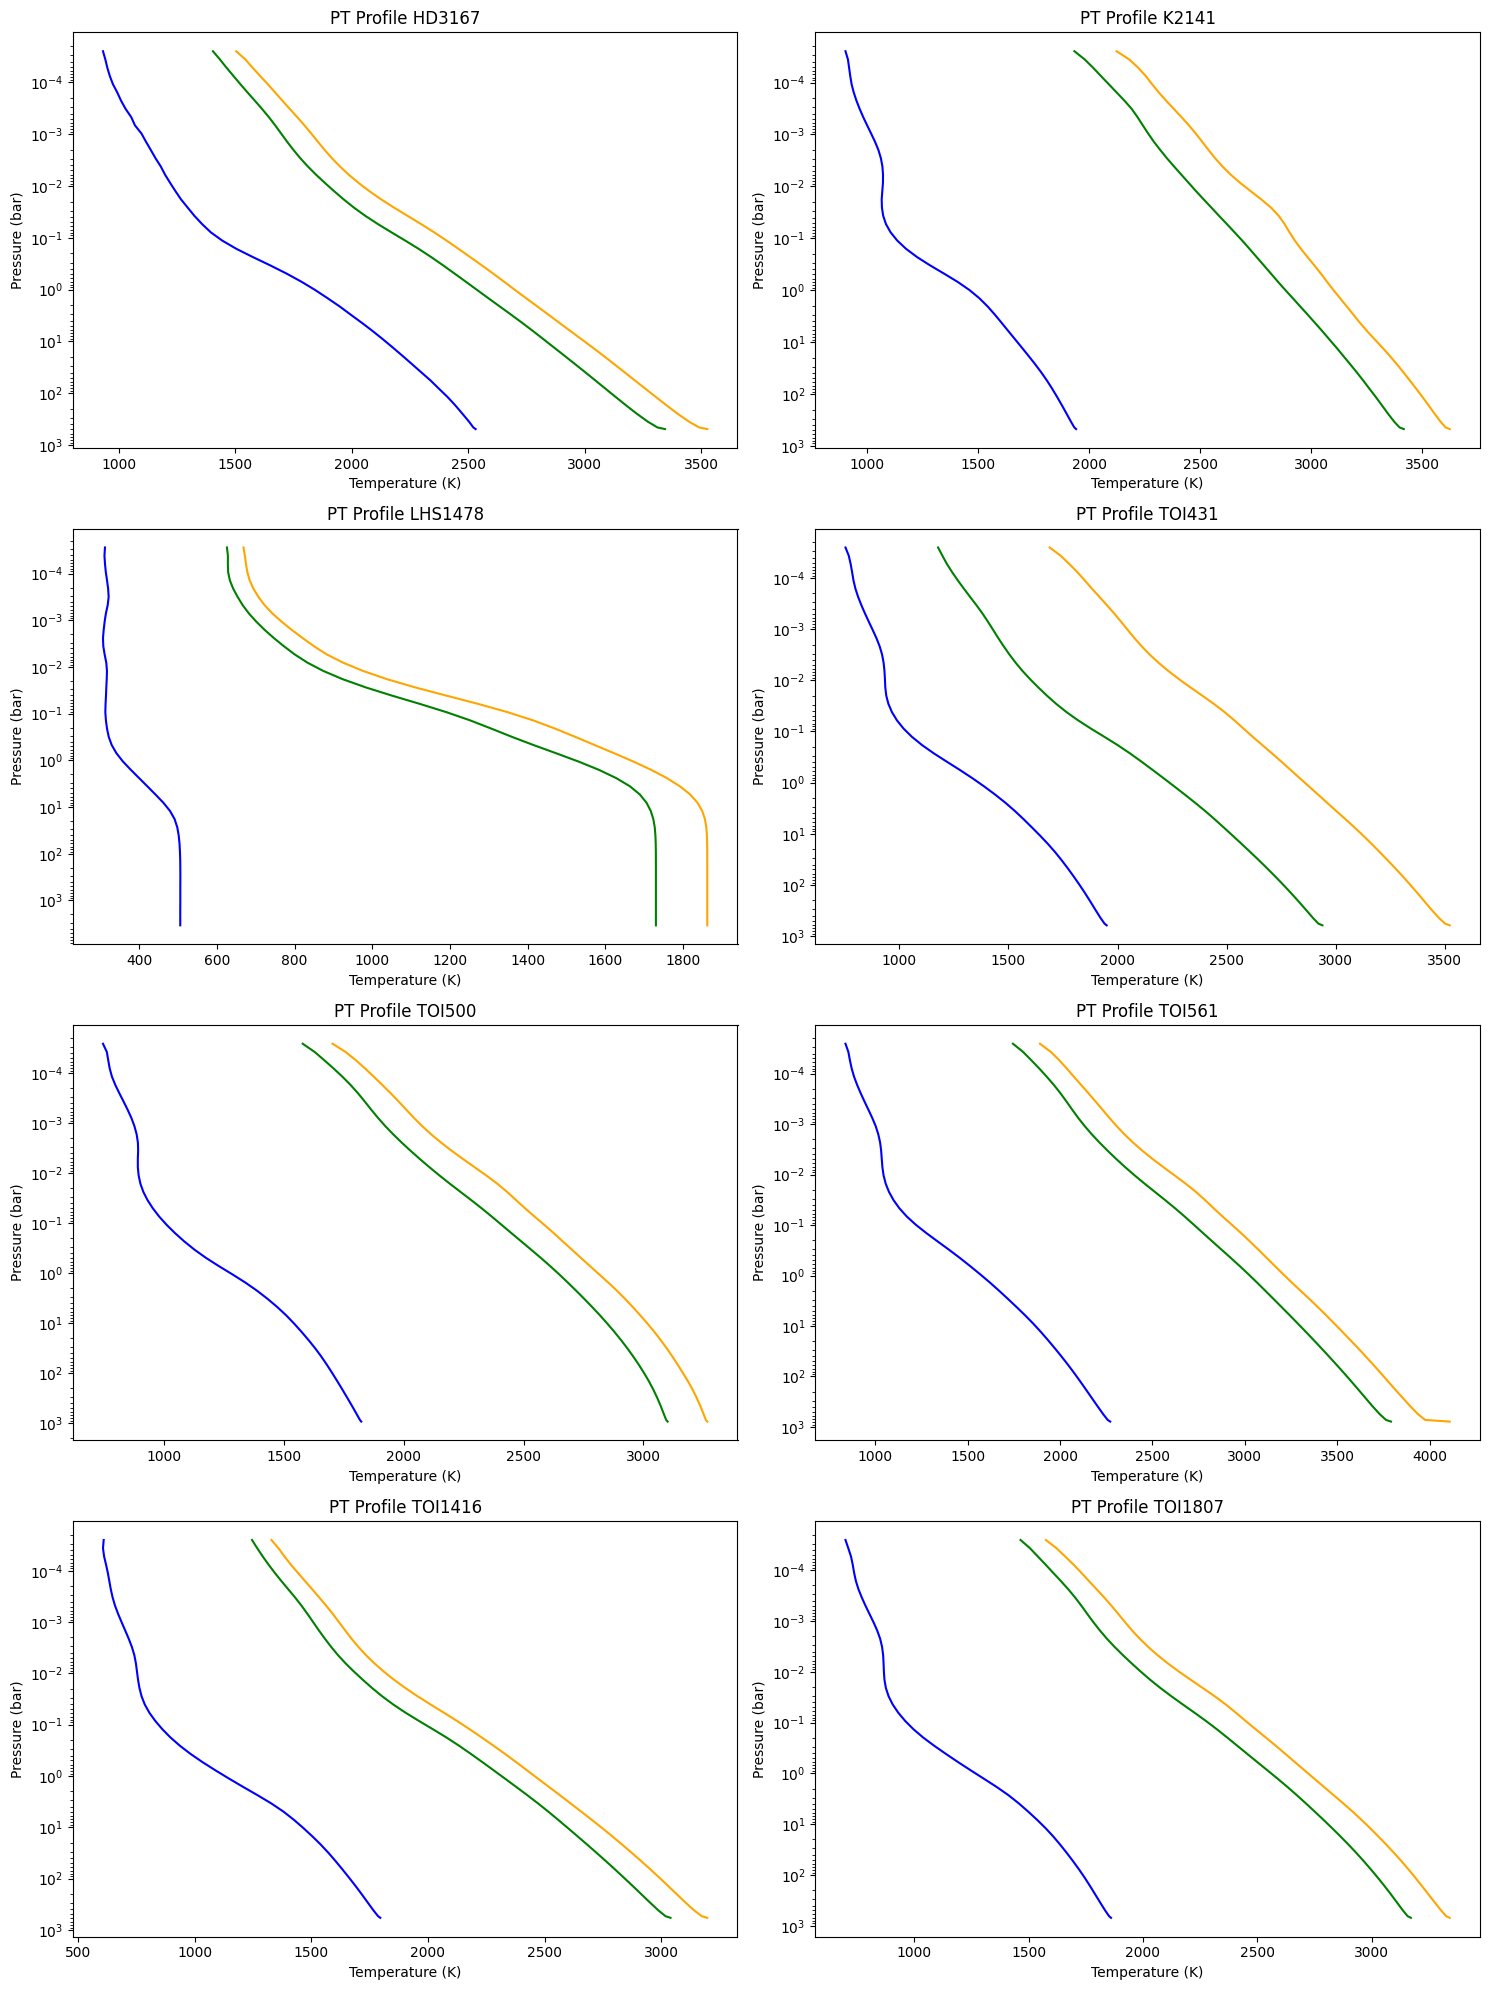

Processing batch: _escape


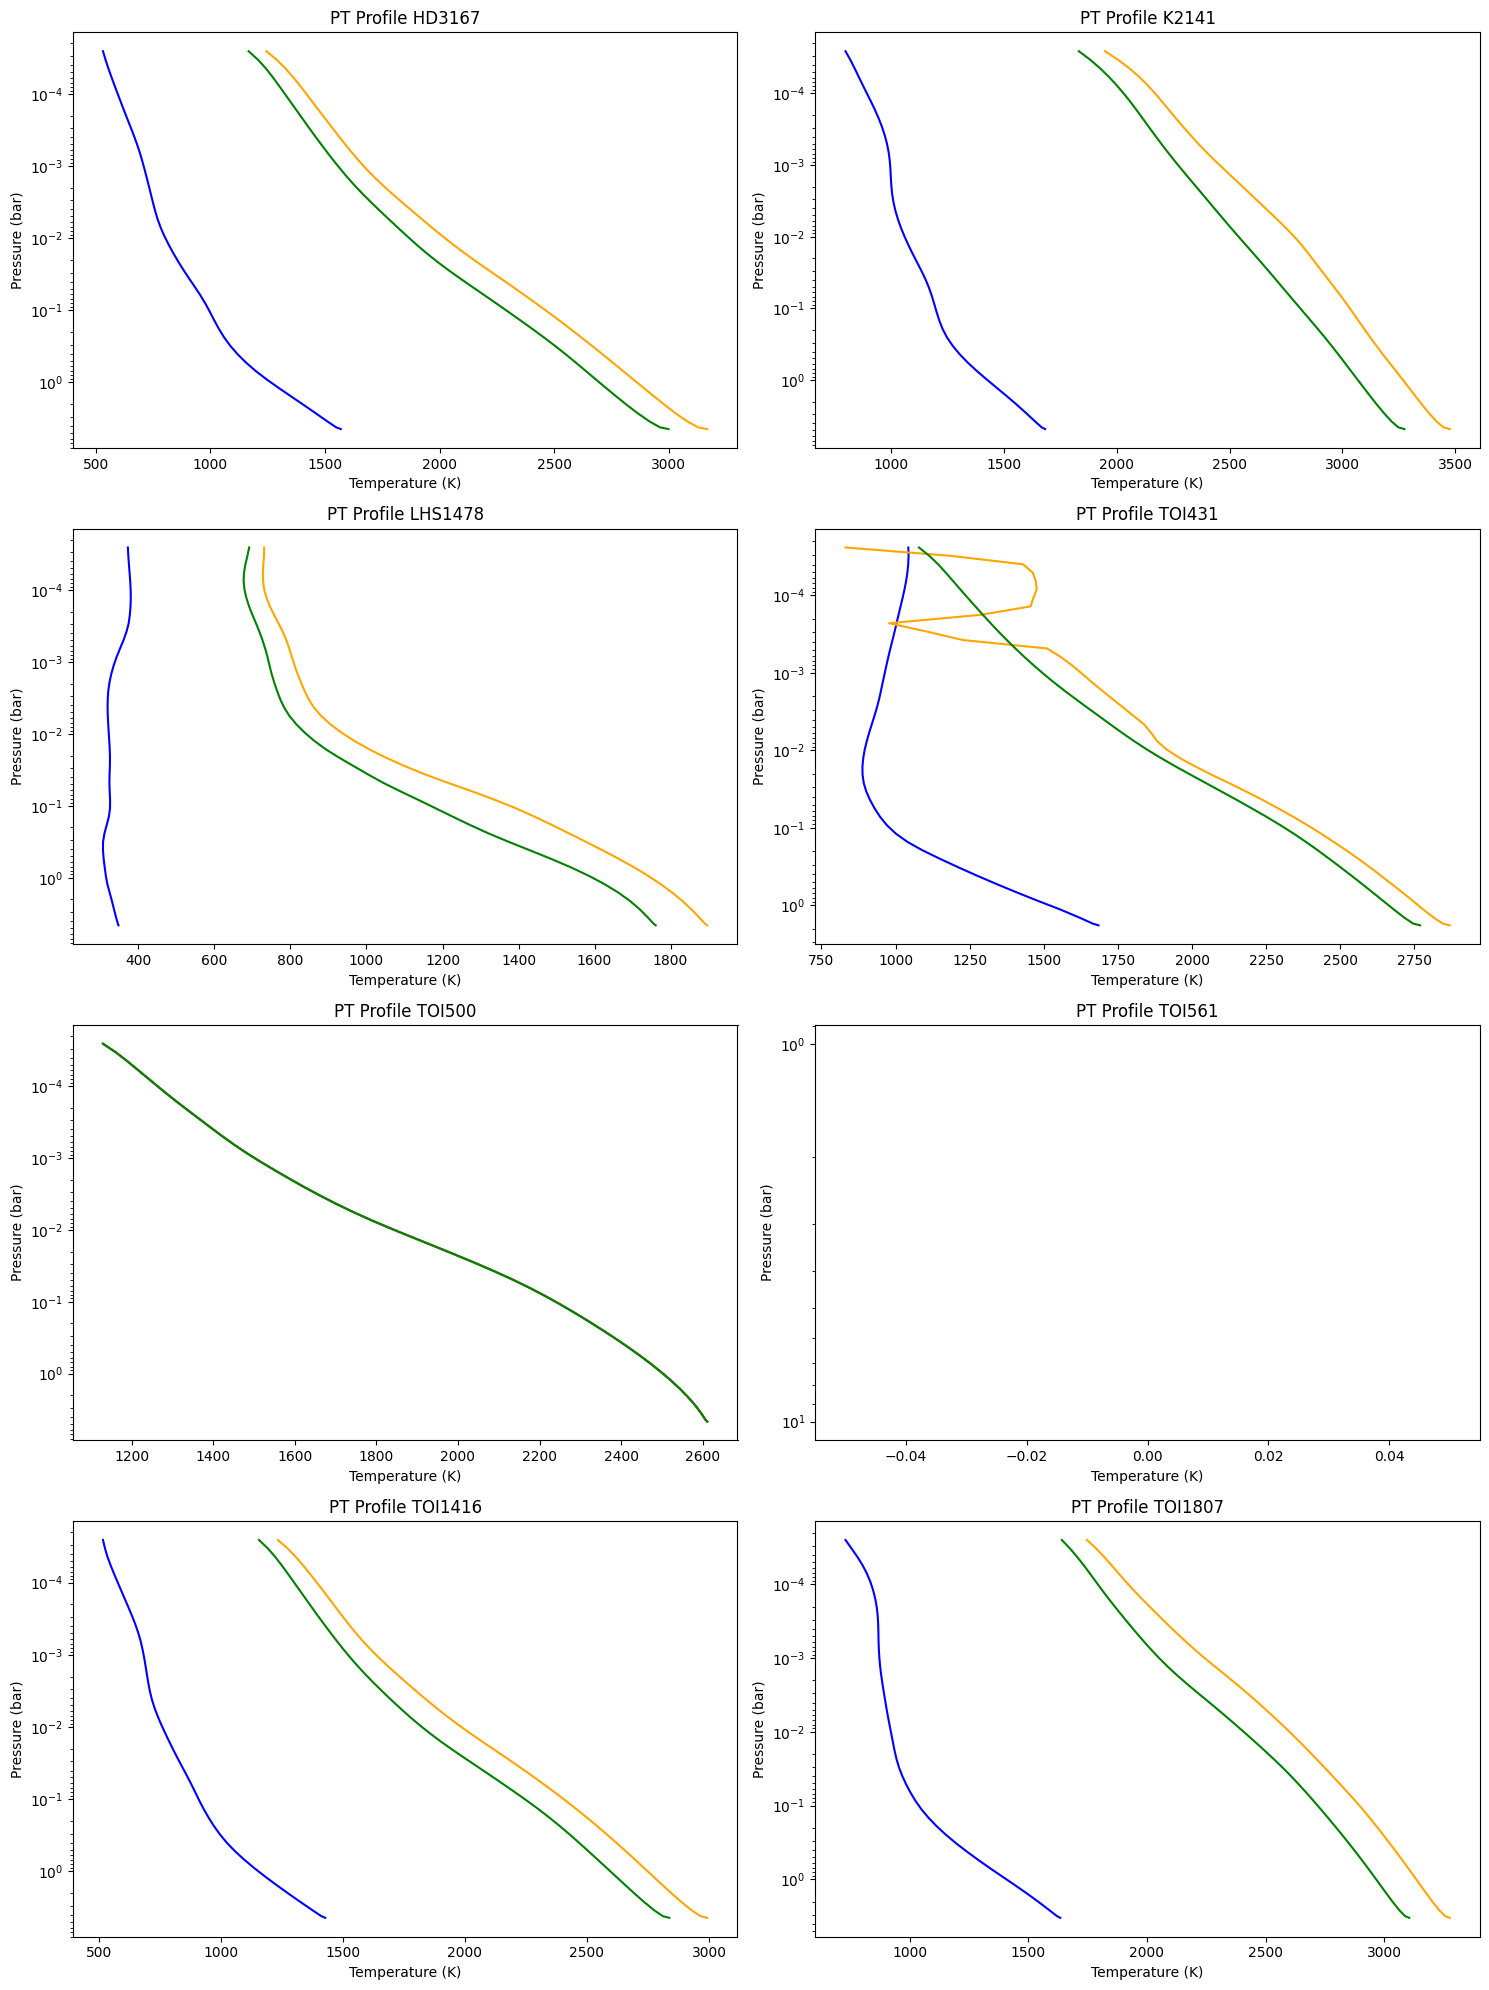

In [8]:
#open the 3 different pressure-temperature .nc files in directory

for batch in batches.keys():
    print(f"Processing batch: {batches[batch]}")
    fig = figure(figsize=(15, 20))

    for i, name in enumerate(planet_names):
        if batch == 0:
            name = name
        elif batch == 1:
            name = f"{name}_1"
        elif batch == 2:
            name = f"{name}_10"
        elif batch == 3:
            name = f"{name}_escape"
        else:
            print("Invalid batch selection.")
            continue

        for file in os.listdir(f"PLANETS/{name}/"):
            if file.endswith("atm.nc"):
                atm_file = os.path.join(f"PLANETS/{name}/", file)
                #save filename without extension
                filename = os.path.splitext(atm_file)[0]
                break

        ds = xr.open_dataset(atm_file)

        #list all variables in dataset
        #for var in ds.variables:
        #    print(f"  {var}")

        #extract pressure and temperature profiles
        pressure = np.array(ds['p']) #pressure in Pa
        pressure = pressure / 1e5 #convert to bar

        #mask for low pressure feature
        p_limit = 2e-5 #pressure limit in bar
        mask = pressure >= p_limit
        pressure = pressure[mask]

        #extract original temperature profile
        temperature = np.array(ds['tmp'])[mask]

        substellar = xr.open_dataset(f"{filename}_z0.nc")
        average = xr.open_dataset(f"{filename}_z45.nc")
        terminator = xr.open_dataset(f"{filename}_z89.nc")

        t_terminator = np.array(terminator['temperature'])[mask]
        t_average = np.array(average['temperature'])[mask]
        t_substellar = np.array(substellar['temperature'])[mask]

        # Create the plot
        frame = fig.add_subplot(4, 2, i+1)

        frame.plot(t_terminator, pressure, c='blue', label='Terminator Profile')
        frame.plot(t_substellar, pressure, c='orange', label='Substellar Profile')
        frame.plot(t_average, pressure, c='green', label='Average Profile')

        plt.yscale('log')
        plt.ylabel('Pressure (bar)')
        plt.gca().invert_yaxis()
        plt.xlabel('Temperature (K)')
        plt.title(f'PT Profile {name[:name.find("_")] if "_" in name else name}')

    #make sure the figure saves even if no file is there
    plt.tight_layout()
    savefig(f"plots/TP_{batch}.pdf", format='pdf', dpi=300, bbox_inches='tight')
    show()
    close()

## Open T-P profile

In [12]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
#[0: standard; 1: 1 H ocean; 2: 10 H ocean; 3: escape]
batches = [0,1,2,3]

for batch in batches:
    for i, name in enumerate(planet_names):
        #find only file ending in atm.nc
        atm_file = None

        if batch == 0:
            name = name
        elif batch == 1:
            name = f"{name}_1"
        elif batch == 2:
            name = f"{name}_10"
        elif batch == 3:
            name = f"{name}_escape"
        else:
            print("Invalid batch selection.")
            continue

        for file in os.listdir(f"PLANETS/{name}/"):
            if file.endswith("atm.nc"):
                atm_file = os.path.join(f"PLANETS/{name}/", file)
                #save filename without extension
                filename = os.path.splitext(atm_file)[0]
                break
        
        # Load the dataset
        ds = xr.open_dataset(atm_file)
        #list all variables in the dataset
        #print(ds.data_vars)

        #extract gas names
        gases = np.array(ds['gases'])
        gases = [m.decode().strip() for m in ds["gases"].values]

        #extract pressure and temperature profiles
        pressure = np.array(ds['p']) #pressure in Pa
        pressure = pressure / 1e5 #convert to bar

        #mask for low pressure feature
        p_limit = 2e-5 #pressure limit in bar
        mask = pressure >= p_limit
        pressure = pressure[mask]

        #extract original temperature profile
        temperature = np.array(ds['tmp'])[mask]

        substellar = xr.open_dataset(f"{filename}_z0.nc")
        average = xr.open_dataset(f"{filename}_z45.nc")
        terminator = xr.open_dataset(f"{filename}_z89.nc")

        t_terminator = np.array(terminator['temperature'])[mask]
        t_average = np.array(average['temperature'])[mask]
        t_substellar = np.array(substellar['temperature'])[mask]

        # Create the plot
        fig = figure(figsize=(6, 5))
        frame = fig.add_subplot(1, 1, 1)

        frame.plot(t_terminator, pressure, c='blue', label='Terminator Profile')
        frame.plot(t_substellar, pressure, c='orange', label='Substellar Profile')
        frame.plot(t_average, pressure, c='green', label='Average Profile')

        plt.yscale('log')
        plt.ylabel('Pressure (bar)')
        plt.gca().invert_yaxis()
        plt.xlabel('Temperature (K)')
        plt.title(f'PT Profile {name}')
        #plt.grid()
        plt.legend()

        #make sure the figure saves even if no file is there
        savefig(f"plots/{name}_TP.pdf", format='pdf', dpi=300, bbox_inches='tight')
        close()

        #invert order of array
        pressure = pressure[::-1]
        t_terminator = t_terminator[::-1]
        t_average = t_average[::-1]
        t_substellar = t_substellar[::-1]

        #save temperature profiles to a csv file
        temp_df = pd.DataFrame({
            'Pressure (Pa)': pressure*1e5,
            'Terminator Temperature (K)': t_terminator,
            'Substellar Temperature (K)': t_substellar,
            'Average Temperature (K)': t_average
        })
        temp_df.to_csv(f"PLANETS/{name}/{name}_TP.csv", index=False)

        #chemical profiles
        vmr = np.array(ds['x_gas'])

        fig = figure(figsize=(8, 7))
        frame = fig.add_subplot(1, 1, 1)

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        linestyles = ["-", "--", "-.", ":"]

        color_cycle = itertools.cycle(colors)
        style_cycle = itertools.cycle(linestyles)

        #match gas names with vmr profiles
        for i, gas in enumerate(gases):
            vmr_gas = vmr[:, i][mask]
            c = next(color_cycle)
            s = next(style_cycle) if i % len(colors) == 0 else s  # reset linestyle when colors cycle
            frame.plot(vmr_gas, pressure, label=gas,color=c,linestyle=s)

        frame.set_xscale('log')
        frame.set_yscale('log')
        frame.invert_yaxis()
        frame.set_xlabel('Volume Mixing Ratio (VMR)')
        frame.set_ylabel('Pressure (bar)')
        frame.set_title(f'VMR Profiles {name}')
        #frame.grid()
        frame.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        savefig(f"plots/{name}_vmr.pdf", format='pdf', dpi=300, bbox_inches='tight')

        close()


/var/folders/d2/y_z191q963g92trgn9c1vkl80000gn/T/ipykernel_62824/4234761909.py:114: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  frame.invert_yaxis()
/var/folders/d2/y_z191q963g92trgn9c1vkl80000gn/T/ipykernel_62824/4234761909.py:114: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  frame.invert_yaxis()
